### Importação dos dados



In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']

#1. Análise do faturamento



In [84]:
loja['Faturamento'] = loja['Preço'] + loja['Frete']
loja2['Faturamento'] = loja2['Preço'] + loja2['Frete']
loja3['Faturamento'] = loja3['Preço'] + loja3['Frete']
loja4['Faturamento'] = loja4['Preço'] + loja4['Frete']

faturamentos = [
    loja['Faturamento'].sum(),
    loja2['Faturamento'].sum(),
    loja3['Faturamento'].sum(),
    loja4['Faturamento'].sum()
]

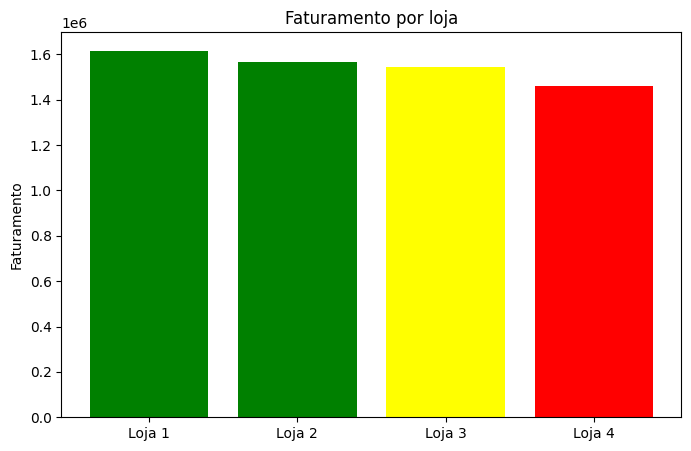

In [117]:
min_index = faturamentos.index(min(faturamentos))
media_valor = sum(faturamentos) / len(faturamentos)
media_index = min(range(len(faturamentos)), key=lambda i: abs(faturamentos[i] - media_valor))

# Criar lista de cores
colors = ['green'] * len(faturamentos)
colors[min_index] = 'red'      # pior
colors[media_index] = 'yellow' # médio

# Plotar gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(lojas, faturamentos, color=colors)
plt.title('Faturamento por loja')
plt.ylabel('Faturamento')
plt.show()

# 2. Vendas por Categoria

In [111]:
vendas_por_categoria = pd.DataFrame({
    'Loja 1': loja['Categoria do Produto'].value_counts(),
    'Loja 2': loja2['Categoria do Produto'].value_counts(),
    'Loja 3': loja3['Categoria do Produto'].value_counts(),
    'Loja 4': loja4['Categoria do Produto'].value_counts()
}).fillna(0)

total_vendas_lojas = vendas_por_categoria.sum()

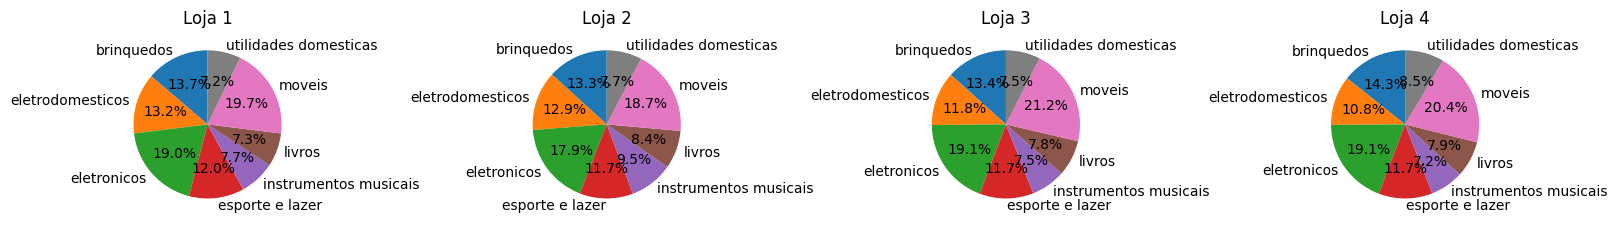

In [114]:
lojas = vendas_por_categoria.columns
num_lojas = len(lojas)

# Criar subplots lado a lado
fig, axes = plt.subplots(1, num_lojas, figsize=(4*num_lojas, 4))  # 1 linha, N colunas

for i, loja_nome in enumerate(lojas):
    dados = vendas_por_categoria[loja_nome]

    axes[i].pie(dados, labels=dados.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{loja_nome}')

plt.tight_layout()
plt.show()

# 3. Média de Avaliação das Lojas


In [65]:
avaliacoes = [
    loja['Avaliação da compra'].mean(),
    loja2['Avaliação da compra'].mean(),
    loja3['Avaliação da compra'].mean(),
    loja4['Avaliação da compra'].mean()
]

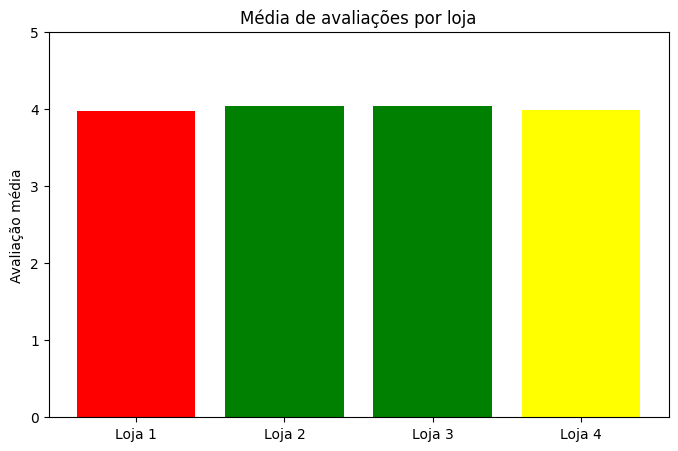

In [118]:
min_index = avaliacoes.index(min(avaliacoes))
media_valor = sum(avaliacoes) / len(avaliacoes)
media_index = min(range(len(avaliacoes)), key=lambda i: abs(avaliacoes[i] - media_valor))

# Criar lista de cores
colors = ['green'] * len(avaliacoes)
colors[min_index] = 'red'      # pior
colors[media_index] = 'yellow' # média

# Plotar gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(lojas, avaliacoes, color=colors)
plt.title('Média de avaliações por loja')
plt.ylabel('Avaliação média')
plt.ylim(0, 5)  # assumindo que a nota vai de 0 a 5
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [64]:
mais_vendidos = [
    loja['Categoria do Produto'].value_counts().idxmax(),
    loja2['Categoria do Produto'].value_counts().idxmax(),
    loja3['Categoria do Produto'].value_counts().idxmax(),
    loja4['Categoria do Produto'].value_counts().idxmax()
]

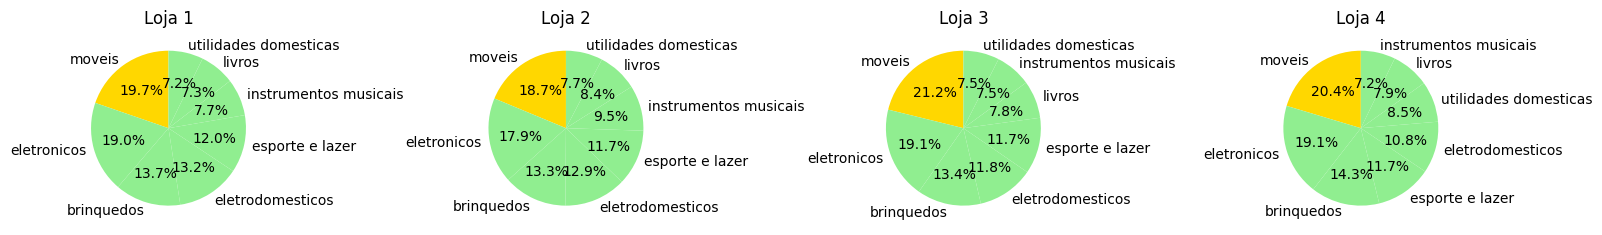

In [120]:
num_lojas = len(lojas)

# Criar subplots lado a lado
fig, axes = plt.subplots(1, num_lojas, figsize=(4*num_lojas, 4))  # 1 linha, N colunas

for i, loja_nome in enumerate(lojas):
    # Selecionar dados da loja
    if i == 0:
        dados = loja['Categoria do Produto'].value_counts()
    elif i == 1:
        dados = loja2['Categoria do Produto'].value_counts()
    elif i == 2:
        dados = loja3['Categoria do Produto'].value_counts()
    else:
        dados = loja4['Categoria do Produto'].value_counts()

    # Criar cores: destacar a categoria mais vendida
    colors = ['gold' if cat == dados.idxmax() else 'lightgreen' for cat in dados.index]

    axes[i].pie(dados, labels=dados.index, autopct='%1.1f%%', startangle=90, colors=colors)
    axes[i].set_title(loja_nome)

plt.tight_layout()
plt.show()

In [63]:
menos_vendidos = [
    loja['Categoria do Produto'].value_counts().idxmin(),
    loja2['Categoria do Produto'].value_counts().idxmin(),
    loja3['Categoria do Produto'].value_counts().idxmin(),
    loja4['Categoria do Produto'].value_counts().idxmin()
]

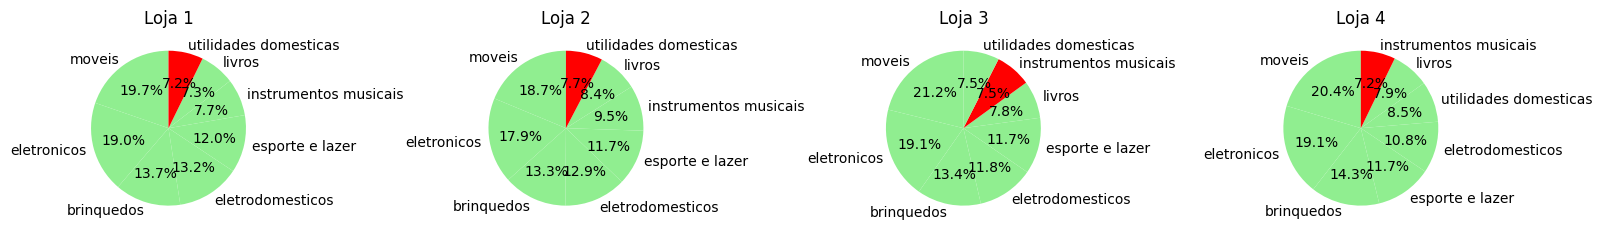

In [121]:
num_lojas = len(lojas)

# Criar subplots lado a lado
fig, axes = plt.subplots(1, num_lojas, figsize=(4*num_lojas, 4))  # 1 linha, N colunas

for i, loja_nome in enumerate(lojas):
    # Selecionar dados da loja
    if i == 0:
        dados = loja['Categoria do Produto'].value_counts()
    elif i == 1:
        dados = loja2['Categoria do Produto'].value_counts()
    elif i == 2:
        dados = loja3['Categoria do Produto'].value_counts()
    else:
        dados = loja4['Categoria do Produto'].value_counts()

    # Criar cores: destacar a categoria menos vendida
    colors = ['red' if cat == dados.idxmin() else 'lightgreen' for cat in dados.index]

    axes[i].pie(dados, labels=dados.index, autopct='%1.1f%%', startangle=90, colors=colors)
    axes[i].set_title(loja_nome)

plt.tight_layout()
plt.show()

# 5. Frete Médio por Loja

In [62]:
fretes = [
    loja['Frete'].mean(),
    loja2['Frete'].mean(),
    loja3['Frete'].mean(),
    loja4['Frete'].mean()
]

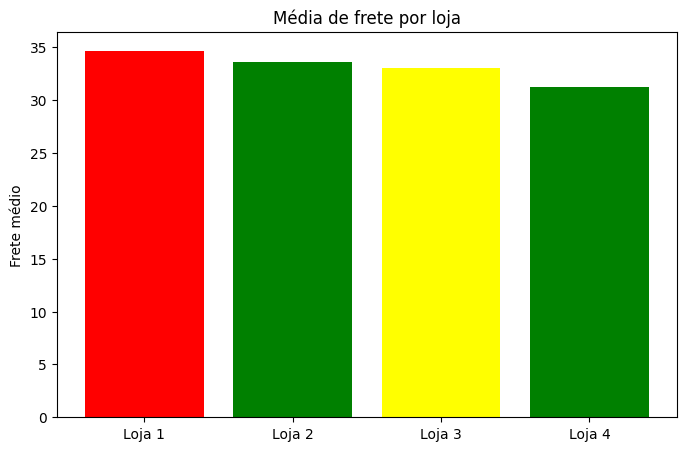

In [123]:
# Identificar maior frete (pior) e o mais próximo da média
max_index = fretes.index(max(fretes))  # maior frete = ruim
media_valor = sum(fretes) / len(fretes)
media_index = min(range(len(fretes)), key=lambda i: abs(fretes[i] - media_valor))

# Criar cores: verde para bom (menor frete), vermelho para pior (maior frete), amarelo para média
colors = ['green'] * len(fretes)
colors[max_index] = 'red'      # pior frete (maior)
colors[media_index] = 'yellow' # próximo da média

# Plotar gráfico de barras
plt.figure(figsize=(8,5))
plt.bar(lojas, fretes, color=colors)
plt.title('Média de frete por loja')
plt.ylabel('Frete médio')
plt.show()

De acordo com a analise de dado a loja mais indicada para ser vendida é a loja 4.

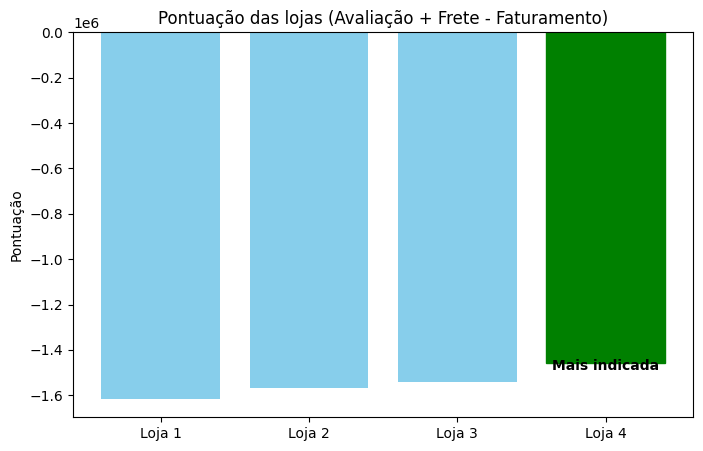

In [124]:
pontuacao = [(a + f) - ft for a, f, ft in zip(avaliacoes, fretes, faturamentos)]

# Plotar gráfico de barras
plt.figure(figsize=(8,5))
bars = plt.bar(lojas, pontuacao, color='skyblue')
plt.title('Pontuação das lojas (Avaliação + Frete - Faturamento)')
plt.ylabel('Pontuação')

# Destacar a loja mais indicada
melhor_index = np.argmax(pontuacao)
bars[melhor_index].set_color('green')
plt.text(melhor_index, pontuacao[melhor_index]+0.02*max(pontuacao), 'Mais indicada', ha='center', fontweight='bold')

plt.show()